### 21. Image to character painting
#### (a) Target
Converting the RGB color image to character painting with Python code
- Character painting is a combination of a series of characters. We can think of characters as relatively large pixels. A character can represent a color. The more types of characters, the more colors can be represented, and the picture will be more hierarchical sense

#### (b) Requirements
- Python 3.5
- pillow 5.1.0

#### (c) Method
i. Use PIL (pillow) to get the input picture
ii. Use the following formula to map RGB values to gray values (note that this formula is not a real algorithm, but a simplified sRGB IEC61966-2.1 formula)
  - $gray = 0.2126 * r + 0.7152 * g + 0.0722 * b$
iii. Create a character list (length and content are customized)
iv. Map the gray value to characters and save the result with a string (note the corresponding picture size, add line breaks)
v. Export character painting to a `.txt` file

#### (d) Result
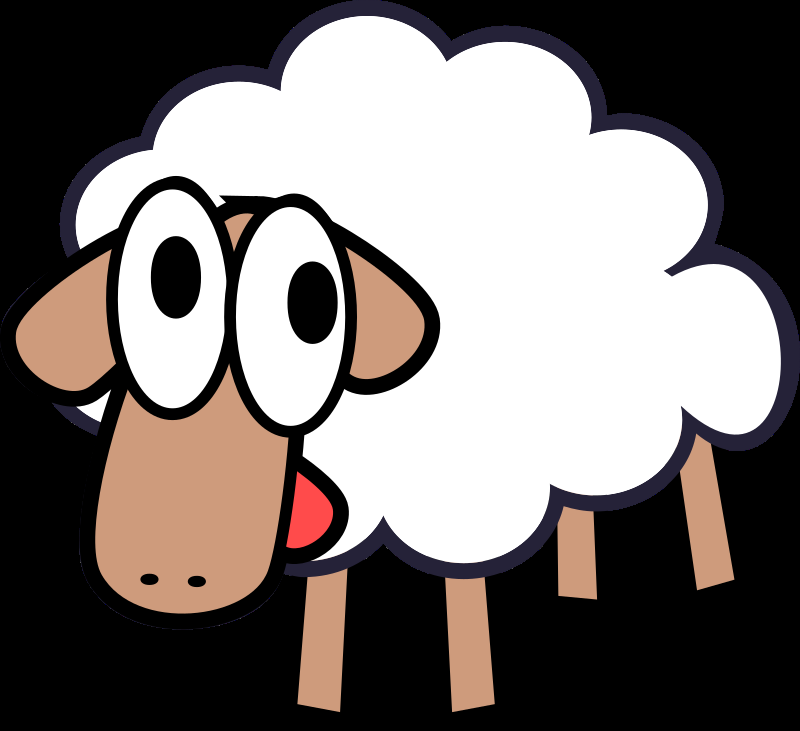
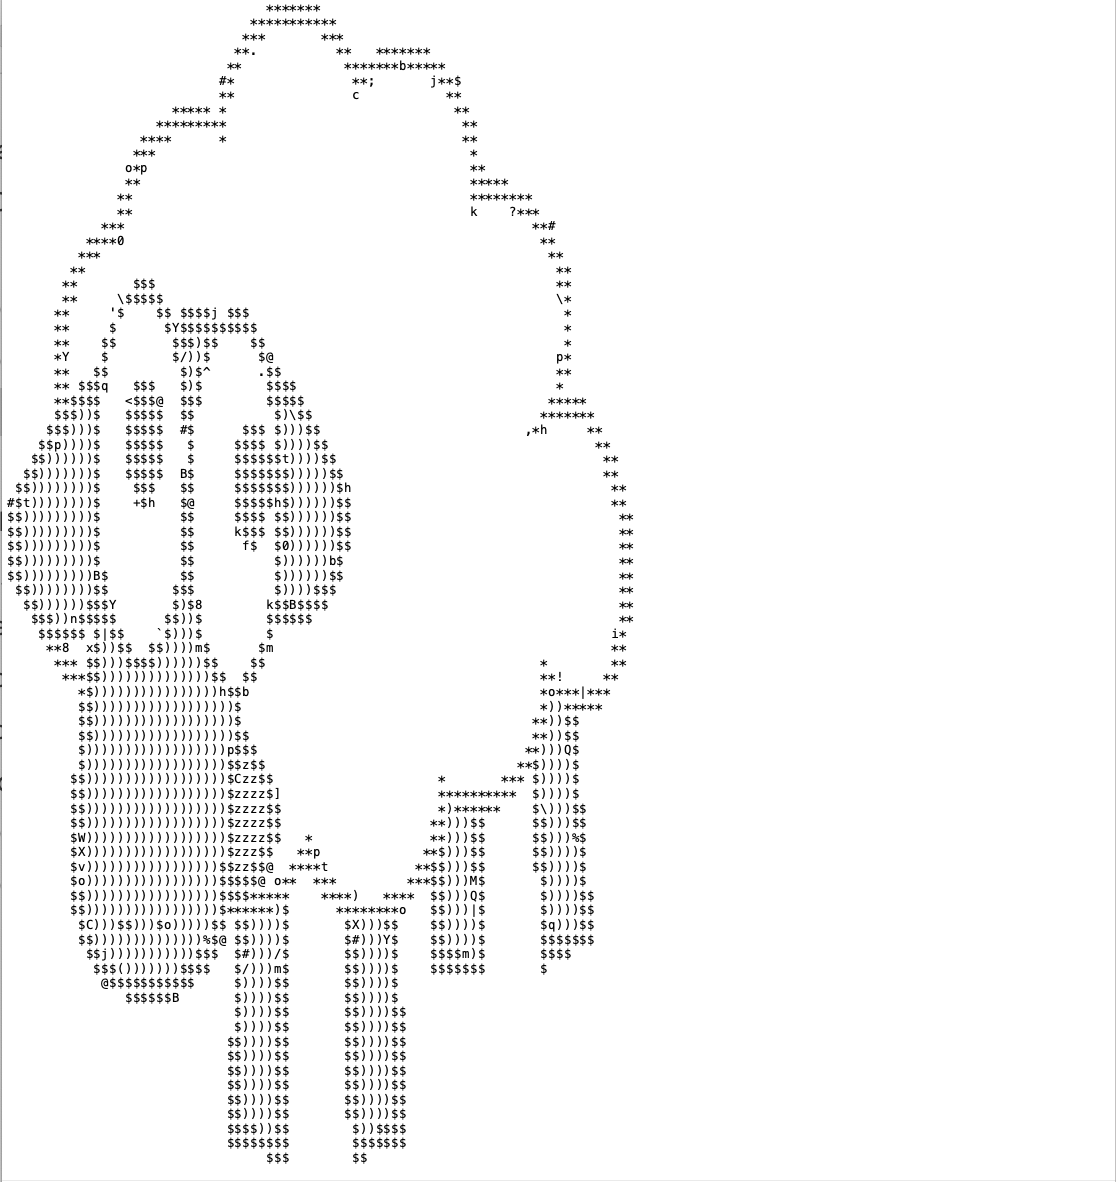

In [ ]:
from PIL import Image


def image_to_ascii(input_path, output_txt, width=120):
    chars = "@%#*+=-:. "

    img = Image.open(input_path).convert("RGB")
    w, h = img.size

    # 字符高度通常大于宽度，这里用 0.5 做纵横比修正
    new_height = max(1, int(h * width / w * 0.5))
    img = img.resize((width, new_height))

    lines = []
    pixels = img.load()
    for y in range(new_height): #逐行扫描图像
        row = []
        for x in range(width):
            r, g, b = pixels[x, y]  #直接访问每个像素的 (r, g, b)
            gray = 0.2126 * r + 0.7152 * g + 0.0722 * b
            idx = int(gray / 255 * (len(chars) - 1))   #映射到[0,len(char)-1]
            row.append(chars[idx])
        lines.append("".join(row))

    ascii_art = "\n".join(lines)
    with open(output_txt, "w", encoding="utf-8") as f:
        f.write(ascii_art)
    return ascii_art

image_path = "image.png"
output_txt = "ascii_art.txt"


ascii_result = image_to_ascii(image_path, output_txt, width=120)
print(ascii_result)


...............................................:=+##%%%%%%##+=:.........................................................
............................................:+#%#*+=-::::-=+*#%#+:.........::...........................................
..........................................:*%%+:..............:+%%+::=+##%%%%%%##+=:....................................
.........................................-%%+....................=%%%#+=-::::::-=*#%#+:.................................
..................................::::..-%%-......................:=...............:+%%*:...............................
............................-+*#%%%%%%%#%@=...........................................+@%-..............................
.........................-*%%*+-::...::-=+.............................................-%%-.............................
.......................-#%*-............................................................+@#.............................
......................=@#-......

### 22. Numpy exercises
- Consider a random 10×2 matrix representing cartesian coordinates, convert them to polar coordinates.
- Create a 2D array subclass such that $Z[i, j] == Z[j, i]$.
- Consider 2 sets of points P0, P1 describing lines (2d) and a set of points P, how to compute distance from each point j (P[j]) to each line i (P0[i],P1[i])?

In [ ]:
import numpy as np

# (1) 10x2 笛卡尔坐标 -> 极坐标
points = np.random.rand(10, 2) * 10
x = points[:, 0]
y = points[:, 1]
r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)
polar = np.hstack((r, theta))
print("Cartesian:\n", points)
print("Polar (r, theta):\n", polar)


# (2) 让 Z[i,j] == Z[j,i] 的 2D 子类
# 继承 np.ndarray
# 在创建对象时检查它是不是二维、是不是方阵
# 重写 __getitem__（取值）
# 让 (i, j) 和 (j, i) 访问同一个位置
# 重写 __setitem__（赋值）
# 给 Z[i, j] 赋值时，同时更新 Z[j, i]
class SymmetricArray(np.ndarray):
    def __new__(cls, input_array):
        arr = np.asarray(input_array)
        if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:   #array.ndim 返回数组的维数，array.shape 返回数组的形状
            raise ValueError("SymmetricArray requires a square 2D array.")
        obj = arr.view(cls)
        return obj

    def __setitem__(self, key, value):
        if (
            isinstance(key, tuple)
            and len(key) == 2
            and isinstance(key[0], (int, np.integer))
            and isinstance(key[1], (int, np.integer))
        ):
            i, j = key
            super().__setitem__((i, j), value)
            super().__setitem__((j, i), value)
        else:
            super().__setitem__(key, value)


Z = SymmetricArray(np.zeros((4, 4)))
Z[1, 3] = 9
print("Symmetric Z:\n", Z)


# (3) 点到线的距离：每个点 P[j] 到每条线 (P0[i], P1[i])
def point_to_lines_distances(P0, P1, P):
    P0 = np.asarray(P0, dtype=float)
    P1 = np.asarray(P1, dtype=float)
    P = np.asarray(P, dtype=float)

    line_vec = P1 - P0  # (L,2)
    line_len = np.linalg.norm(line_vec, axis=1)  # (L,)
    if np.any(line_len == 0):
        raise ValueError("A line has zero length.")

    # 2D 叉积标量 |(P-P0) x (P1-P0)| / |P1-P0|
    diff = P[None, :, :] - P0[:, None, :]  # (L,M,2),第一维度用P0的，第二维度用P的
    cross = np.abs(diff[:, :, 0] * line_vec[:, None, 1] - diff[:, :, 1] * line_vec[:, None, 0])  # (L,M)
    d = cross / line_len[:, None]  # (L,M)
    return d.T  # 返回 (M,L): 每个点到每条线


P0 = np.array([[0, 0], [1, 1], [0, 2]])
P1 = np.array([[1, 0], [3, 1], [2, 2]])
P = np.array([[0, 1], [2, 3]])
D = point_to_lines_distances(P0, P1, P)
print("Distance matrix (points x lines):\n", D)


Cartesian:
 [[2.78490099 0.92897013]
 [6.39807497 8.06706072]
 [0.71005667 0.1481824 ]
 [1.91092376 9.92512837]
 [8.76503655 2.49550505]
 [5.18815606 7.0456509 ]
 [4.92710481 1.8986998 ]
 [7.14362233 3.97905714]
 [9.42318474 7.26749551]
 [6.80264432 8.25124758]]
Polar (r, theta):
 [ 2.93575527 10.29625329  0.72535405 10.10741326  9.11336443  8.74975199
  5.28028623  8.17705544 11.90012191 10.69387939  0.321967    0.9002701
  0.2057381   1.3805899   0.27737214  0.93608023  0.36782069  0.50820796
  0.65695394  0.88133061]
Symmetric Z:
 [[0. 0. 0. 0.]
 [0. 0. 0. 9.]
 [0. 0. 0. 0.]
 [0. 9. 0. 0.]]
Distance matrix (points x lines):
 [[1. 0. 1.]
 [3. 2. 1.]]


### 23. Bilinear Interpolation
Please implement the bilinear interpolation algorithm using python. Check this for an introduction to bilinear interpolation.

Test samples:
```python
A = (
    ((110, 120, 130),
     (210, 220, 230),
     (310, 320, 330))
)
BilinearInterpolation(A, (1, 1)) == 110
BilinearInterpolation(A, (2.5, 2.5)) == 275

In [ ]:
import math


def BilinearInterpolation(A, point):
    # A: 2D 数组(或嵌套列表)，point: (x, y)，采用 1-based 坐标
    x, y = point
    h = len(A)
    w = len(A[0])
    if h == 0 or w == 0:
        raise ValueError("Empty array.")

    # 转换为 0-based 连续坐标
    x0f = x - 1.0
    y0f = y - 1.0

    # 边界截断
    x0f = min(max(x0f, 0.0), w - 1.0)
    y0f = min(max(y0f, 0.0), h - 1.0)

    x1 = int(math.floor(x0f))
    y1 = int(math.floor(y0f))
    x2 = min(x1 + 1, w - 1)
    y2 = min(y1 + 1, h - 1)

    dx = x0f - x1
    dy = y0f - y1

    Q11 = A[y1][x1]
    Q21 = A[y1][x2]
    Q12 = A[y2][x1]
    Q22 = A[y2][x2]

    top = Q11 * (1 - dx) + Q21 * dx
    bottom = Q12 * (1 - dx) + Q22 * dx
    value = top * (1 - dy) + bottom * dy
    return value


A = (
    (110, 120, 130),
    (210, 220, 230),
    (310, 320, 330),
)
print("BilinearInterpolation(A, (1, 1)) =", BilinearInterpolation(A, (1, 1)))
print("BilinearInterpolation(A, (2.5, 2.5)) =", BilinearInterpolation(A, (2.5, 2.5)))


BilinearInterpolation(A, (1, 1)) = 110.0
BilinearInterpolation(A, (2.5, 2.5)) = 275.0


### 24. Cartesian product
Given an arbitrary number of vectors, build the cartesian product (every combinations of every item).

*e.g.*
`[1, 2, 3], [4, 5], [6, 7] ==> [[1 4 6] [1 4 7] [1 5 6] [1 5 7] [2 4 6] [2 4 7] [2 5 6] [2 5 7] [3 4 6] [3 4 7] [3 5 6] [3 5 7]]`

In [ ]:
import numpy as np


def cartesian_product(*vectors):
    result = [[]]
    for vec in vectors:
        next_result = []
        for prefix in result:
            for item in vec:
                next_result.append(prefix + [item])
        result = next_result
    return np.array(result)


out = cartesian_product([1, 2, 3], [4, 5], [6, 7])
print(out)


[[1 4 6]
 [1 4 7]
 [1 5 6]
 [1 5 7]
 [2 4 6]
 [2 4 7]
 [2 5 6]
 [2 5 7]
 [3 4 6]
 [3 4 7]
 [3 5 6]
 [3 5 7]]


### 25. Extracting a subpart of an array
Consider an arbitrary array, write a function that extract a subpart with a fixed shape and centered on a given element (pad with a `fill` value when necessary)

*e.g.*

**In:**
```python
>>> Z = np.random.randint(0, 10, (5, 5))
>>> shape = (4, 4)
>>> fill = 0
>>> position = (1,1)
>>> Z
[[3 6 8 5 9]
[4 9 0 0 9]
[6 1 4 0 8]
[9 1 2 0 9]
[4 1 7 5 0]]

In [ ]:
import numpy as np


def extract_subpart(Z, shape, position, fill=0):
    Z = np.asarray(Z)
    h, w = shape
    cy, cx = position

    out = np.full((h, w), fill, dtype=Z.dtype if Z.size > 0 else type(fill))

    start_y = cy - h // 2
    start_x = cx - w // 2

    for i in range(h):
        for j in range(w):
            sy = start_y + i
            sx = start_x + j
            if 0 <= sy < Z.shape[0] and 0 <= sx < Z.shape[1]:
                out[i, j] = Z[sy, sx]
    return out


Z = np.random.randint(0, 10, (5, 5))
shape = (4, 4)
fill = 0
position = (1, 1)
print("Z:\n", Z)
print("Subpart:\n", extract_subpart(Z, shape, position, fill))


Z:
 [[3 8 4 0 5]
 [9 7 6 1 1]
 [7 8 3 3 0]
 [3 1 5 8 7]
 [1 0 4 6 4]]
Subpart:
 [[0 0 0 0]
 [0 3 8 4]
 [0 9 7 6]
 [0 7 8 3]]


### 26. Matrix operations
Please implement following matrix (just 2D) operations without numpy:
- add
- subtract
- scalar multiply
- multiply
- identity
- transpose
- inverse

Test samples:

**In:**
```python
>>> matrix_a = [[12, 10], [3, 9]]
>>> matrix_b = [[3, 4], [7, 4]]
>>> matrix_c = [[11, 12, 13, 14], [21, 22, 23, 24], [31, 32, 33, 34], [41, 42, 43, 44]]
>>> matrix_d = [[3, 0, 2], [2, 0, -2], [0, 1, 1]]  
```
**Out:**
```python
add(matrix_a, matrix_b) == [[15, 14], [10, 13]]
subtract(matrix_a, matrix_b) == [[9, 6], [-4, 5]]
scalar_multiply(matrix_b, 3) == [[9, 12], [21, 12]]
multiply(matrix_a, matrix_b) == [[106, 88], [72, 48]]
identity(3) == [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
transpose(matrix_c) == [[11, 21, 31, 41], [12, 22, 32, 42], [13, 23, 33, 43], [14, 24, 34, 44]]
inverse(matrix_d) == [[0.2, 0.2, 0.0], [-0.2, 0.30000000000000004, 1.0], [0.2, -0.30000000000000004, 0.0]]

In [ ]:
def _shape(A):
    if not A or not A[0]:
        raise ValueError("Matrix must be non-empty.")
    return len(A), len(A[0])


def add(A, B):
    ra, ca = _shape(A)
    rb, cb = _shape(B)
    if (ra, ca) != (rb, cb):
        raise ValueError("Shape mismatch.")
    return [[A[i][j] + B[i][j] for j in range(ca)] for i in range(ra)]


def subtract(A, B):
    ra, ca = _shape(A)
    rb, cb = _shape(B)
    if (ra, ca) != (rb, cb):
        raise ValueError("Shape mismatch.")
    return [[A[i][j] - B[i][j] for j in range(ca)] for i in range(ra)]


def scalar_multiply(A, k):
    r, c = _shape(A)
    return [[A[i][j] * k for j in range(c)] for i in range(r)]


def multiply(A, B):
    ra, ca = _shape(A)
    rb, cb = _shape(B)
    if ca != rb:
        raise ValueError("Inner dimensions mismatch.")
    C = [[0 for _ in range(cb)] for _ in range(ra)]
    for i in range(ra):
        for k in range(ca):
            for j in range(cb):
                C[i][j] += A[i][k] * B[k][j]
    return C


def identity(n):
    return [[1 if i == j else 0 for j in range(n)] for i in range(n)]


def transpose(A):
    r, c = _shape(A)
    return [[A[i][j] for i in range(r)] for j in range(c)]


def inverse(A):
    n, m = _shape(A)
    if n != m:
        raise ValueError("Only square matrix has inverse.")

    # 高斯-约旦消元
    aug = [row[:] + id_row[:] for row, id_row in zip(A, identity(n))]

    for col in range(n):
        pivot = col
        while pivot < n and abs(aug[pivot][col]) < 1e-12:
            pivot += 1
        if pivot == n:
            raise ValueError("Matrix is singular.")

        if pivot != col:
            aug[col], aug[pivot] = aug[pivot], aug[col]

        pivot_val = aug[col][col]
        for j in range(2 * n):
            aug[col][j] /= pivot_val

        for i in range(n):
            if i == col:
                continue
            factor = aug[i][col]
            for j in range(2 * n):
                aug[i][j] -= factor * aug[col][j]

    inv = [row[n:] for row in aug]
    return inv


matrix_a = [[12, 10], [3, 9]]
matrix_b = [[3, 4], [7, 4]]
matrix_c = [[11, 12, 13, 14], [21, 22, 23, 24], [31, 32, 33, 34], [41, 42, 43, 44]]
matrix_d = [[3, 0, 2], [2, 0, -2], [0, 1, 1]]

print("add:", add(matrix_a, matrix_b))
print("subtract:", subtract(matrix_a, matrix_b))
print("scalar_multiply:", scalar_multiply(matrix_b, 3))
print("multiply:", multiply(matrix_a, matrix_b))
print("identity:", identity(3))
print("transpose:", transpose(matrix_c))
print("inverse:", inverse(matrix_d))


add: [[15, 14], [10, 13]]
subtract: [[9, 6], [-4, 5]]
scalar_multiply: [[9, 12], [21, 12]]
multiply: [[106, 88], [72, 48]]
identity: [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
transpose: [[11, 21, 31, 41], [12, 22, 32, 42], [13, 23, 33, 43], [14, 24, 34, 44]]
inverse: [[0.19999999999999998, 0.2, 0.0], [-0.2, 0.30000000000000004, 1.0], [0.2, -0.30000000000000004, -0.0]]


### 27. Greatest common divisor
Find the greatest common divisor(gcd) of two integers.

Test samples:
- GCD(3, 5) = 1
- GCD(6, 3) = 3
- GCD(-2, 6) = 2
- GCD(0, 3) = 3

In [ ]:
def GCD(a, b):
    a, b = abs(a), abs(b)
    if a == 0:
        return b
    if b == 0:
        return a
    while b != 0:
        a, b = b, a % b
    return a


print("GCD(3, 5) =", GCD(3, 5))
print("GCD(6, 3) =", GCD(6, 3))
print("GCD(-2, 6) =", GCD(-2, 6))
print("GCD(0, 3) =", GCD(0, 3))


GCD(3, 5) = 1
GCD(6, 3) = 3
GCD(-2, 6) = 2
GCD(0, 3) = 3


### 28. How many ways are there to densely tile a 2 x n floor using 1 x 2 and 2 x 2 tiles

In [ ]:
def count_tilings_2xn(n):
    if n < 0:
        raise ValueError("n must be non-negative.")
    # f(n) = f(n-1) + 2*f(n-2)
    # f(0)=1, f(1)=1
    if n == 0:
        return 1
    if n == 1:
        return 1
    a, b = 1, 1
    for _ in range(2, n + 1):
        a, b = b, b + 2 * a
    return b


for n in range(0, 11):
    print(f"n={n}, ways={count_tilings_2xn(n)}")


n=0, ways=1
n=1, ways=1
n=2, ways=3
n=3, ways=5
n=4, ways=11
n=5, ways=21
n=6, ways=43
n=7, ways=85
n=8, ways=171
n=9, ways=341
n=10, ways=683


### 29. Password checking
A website requires the users to input username and password to register. Write a program to check the validity of password input by users. Following are the criteria for checking the password:
- At least 1 letter between [a-z]
- At least 1 number between [0-9]
- At least 1 letter between [A-Z]
- At least 1 character from [$#@]
- Minimum length of transaction password: 6
- Maximum length of transaction password: 12

Your program should accept a sequence of comma separated passwords and will check them according to the above criteria. Passwords that match the criteria are to be printed, each separated by a comma.

*e.g.*
If the following passwords are given as input to the program: `ABd1234@1,a F1#,2w3E*,2We3345`
Then, the output of the program should be: `ABd1234@1`

In [ ]:
def is_valid_password(pwd):
    if not (6 <= len(pwd) <= 12):
        return False
    has_lower = False
    has_upper = False
    has_digit = False
    has_special = False
    allowed_special = set("$#@")

    for ch in pwd:
        if "a" <= ch <= "z":
            has_lower = True
        elif "A" <= ch <= "Z":
            has_upper = True
        elif "0" <= ch <= "9":
            has_digit = True
        elif ch in allowed_special:
            has_special = True
        else:
            # 其他字符不符合要求
            return False

    return has_lower and has_upper and has_digit and has_special


def filter_passwords(input_string):
    candidates = [p.strip() for p in input_string.split(",")]
    valid = [p for p in candidates if is_valid_password(p)]
    return ",".join(valid)


sample = "ABd1234@1,a F1#,2w3E*,2We3345"
print(filter_passwords(sample))  # ABd1234@1


ABd1234@1
